In [5]:
# class imbalanced = When one class has higher percentage 

# handel class imbalance problem 
# 1 under sampling (down sampling)
# 2 over sampling (up sampling)
# 3 SMOTE

In [6]:
import numpy as np
import pandas as pd

np.random.seed(1) # for reproducibility

no_sample =1000
class_0_ratio =0.9
no_class_0=900
no_class_1=100

In [7]:
no_class_0,no_class_1

(900, 100)

In [8]:
len(np.random.normal(0,1,no_class_0))

900

In [9]:
class_0 ={'feature1':np.random.normal(0,1,no_class_0),
          'feature2':np.random.normal(0,1,no_class_0),
          'target':[0]*no_class_0}

In [10]:
class_0 = pd.DataFrame(class_0)

In [11]:
class_0

,feature1,feature2,target
0,-0.446699,-1.307971,0
1,0.204377,1.472396,0
2,0.612233,0.074876,0
3,0.744885,-1.786935,0
4,-0.036281,0.165211,0
...,...,...,...
895,0.833679,-1.322762,0
896,2.160456,0.540306,0
897,1.998992,-0.507257,0
898,0.764041,1.128379,0


In [12]:
class_1 ={'feature1':np.random.normal(3,1,no_class_1),
          'feature2':np.random.normal(3,1,no_class_1),
          'target':[1]*no_class_1}

In [13]:
class_1=pd.DataFrame(class_1)

In [14]:
class_1

,feature1,feature2,target
0,2.546497,2.965789,1
1,2.179095,2.718501,1
2,3.940219,3.580178,1
3,1.588707,2.136473,1
4,3.884148,3.326813,1
...,...,...,...
95,1.402786,2.274796,1
96,3.461016,2.861925,1
97,4.316506,3.250043,1
98,3.296370,3.353116,1


In [15]:
df=pd.concat([class_0,class_1]).reset_index(drop=True) # this is used for merge two data set 

In [16]:
df

,feature1,feature2,target
0,-0.446699,-1.307971,0
1,0.204377,1.472396,0
2,0.612233,0.074876,0
3,0.744885,-1.786935,0
4,-0.036281,0.165211,0
...,...,...,...
995,1.402786,2.274796,1
996,3.461016,2.861925,1
997,4.316506,3.250043,1
998,3.296370,3.353116,1


In [17]:
df.target.value_counts() #here we see target values 

target
0    900
1    100
Name: count, dtype: int64

In [18]:
#upsampling 

df_minority = df[df.target==1]
df_majority = df[df.target==0]

In [19]:
df_minority

,feature1,feature2,target
900,2.546497,2.965789,1
901,2.179095,2.718501,1
902,3.940219,3.580178,1
903,1.588707,2.136473,1
904,3.884148,3.326813,1
...,...,...,...
995,1.402786,2.274796,1
996,3.461016,2.861925,1
997,4.316506,3.250043,1
998,3.296370,3.353116,1


In [20]:
from sklearn.utils import resample

In [ ]:
#replace = True with replacement
df_minority_upsampled=resample(df_minority,replace=True,n_samples=len(df_majority),random_state=1)

#here we upsampled the minority data >> in simple words make minority data equal to majority data

In [23]:
df_minority_upsampled

,feature1,feature2,target
937,2.885843,2.430835,1
912,2.736919,2.996908,1
972,3.562542,3.088282,1
909,4.750722,2.409355,1
975,2.448677,4.986539,1
...,...,...,...
936,5.729462,2.524350,1
998,3.296370,3.353116,1
901,2.179095,2.718501,1
932,1.375641,1.785627,1


In [24]:
# here we make upsampled data>> concat the df_minority_upsamoled and df_majprity data

df_upsampled=pd.concat([df_minority_upsampled,df_majority])

In [25]:
df_upsampled

,feature1,feature2,target
937,2.885843,2.430835,1
912,2.736919,2.996908,1
972,3.562542,3.088282,1
909,4.750722,2.409355,1
975,2.448677,4.986539,1
...,...,...,...
895,0.833679,-1.322762,0
896,2.160456,0.540306,0
897,1.998992,-0.507257,0
898,0.764041,1.128379,0


In [29]:
df_upsampled.target.value_counts()

target
1    900
0    900
Name: count, dtype: int64

In [ ]:
#Downsampling


In [30]:
df_minority

,feature1,feature2,target
900,2.546497,2.965789,1
901,2.179095,2.718501,1
902,3.940219,3.580178,1
903,1.588707,2.136473,1
904,3.884148,3.326813,1
...,...,...,...
995,1.402786,2.274796,1
996,3.461016,2.861925,1
997,4.316506,3.250043,1
998,3.296370,3.353116,1


In [31]:
df_majority

,feature1,feature2,target
0,-0.446699,-1.307971,0
1,0.204377,1.472396,0
2,0.612233,0.074876,0
3,0.744885,-1.786935,0
4,-0.036281,0.165211,0
...,...,...,...
895,0.833679,-1.322762,0
896,2.160456,0.540306,0
897,1.998992,-0.507257,0
898,0.764041,1.128379,0


In [35]:
df_majority_downsampled=resample(df_majority,replace=False,n_samples=len(df_minority),random_state=1)

In [38]:
df_majority_downsampled

,feature1,feature2,target
860,0.872579,-1.537535,0
880,1.835870,-0.838450,0
874,0.146532,-0.771039,0
780,-0.859827,-2.018355,0
525,0.320971,-0.521316,0
...,...,...,...
494,2.711950,1.152007,0
255,0.522655,-0.241664,0
672,0.683356,-0.999110,0
481,-0.800787,-0.080607,0


In [39]:
df_downsampled = pd.concat([df_majority_downsampled,df_minority])

In [40]:
df_downsampled

,feature1,feature2,target
860,0.872579,-1.537535,0
880,1.835870,-0.838450,0
874,0.146532,-0.771039,0
780,-0.859827,-2.018355,0
525,0.320971,-0.521316,0
...,...,...,...
995,1.402786,2.274796,1
996,3.461016,2.861925,1
997,4.316506,3.250043,1
998,3.296370,3.353116,1


In [ ]:
#SMOTE >> synthetic minority oversampling technique

In [41]:
from sklearn.datasets import make_classification

In [46]:
x,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.90],random_state=1)

In [47]:
x

array([[ 1.53682958, -1.39869399],
       [ 1.55110839,  1.81032905],
       [ 1.29361936,  1.01094607],
       ...,
       [-0.55662536, -0.15983725],
       [ 1.00499902,  0.93628981],
       [ 1.46210987,  1.14497791]], shape=(1000, 2))

In [48]:
y

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [52]:
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])

final_df = pd.concat([df1,df2],axis=1)

In [53]:
final_df

,f1,f2,target
0,1.536830,-1.398694,1
1,1.551108,1.810329,0
2,1.293619,1.010946,0
3,1.119889,1.632518,0
4,1.042356,1.121529,0
...,...,...,...
995,2.210439,2.006772,0
996,1.910941,2.011860,0
997,-0.556625,-0.159837,0
998,1.004999,0.936290,0


In [55]:
final_df.target.value_counts()

target
0    894
1    106
Name: count, dtype: int64

In [56]:
import matplotlib.pyplot as plt

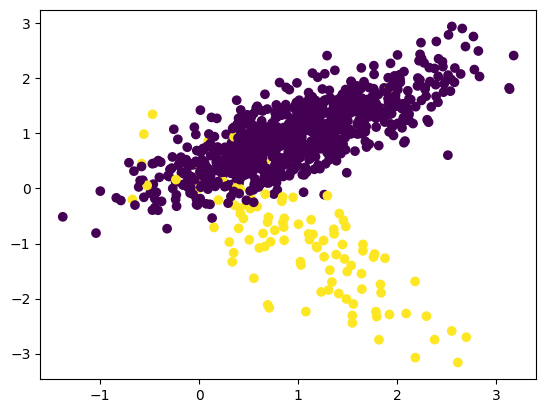

In [ ]:
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [ ]:
#here we see how to implement SMOTE...

In [68]:
pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]
Note: you may need to restart the kernel to use updated packages.


In [69]:
from imblearn .over_sampling import SMOTE

In [70]:
oversample =  SMOTE()

In [72]:
x,y =oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [73]:
x.shape

(1788, 2)

In [74]:
y.shape

(1788,)

In [75]:
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])

oversample_df = pd.concat([df1,df2],axis=1)

In [76]:
oversample_df

,f1,f2,target
0,1.536830,-1.398694,1
1,1.551108,1.810329,0
2,1.293619,1.010946,0
3,1.119889,1.632518,0
4,1.042356,1.121529,0
...,...,...,...
1783,0.841128,-0.151986,1
1784,2.226731,-3.082333,1
1785,1.641591,-1.576702,1
1786,-0.117810,-0.031906,1


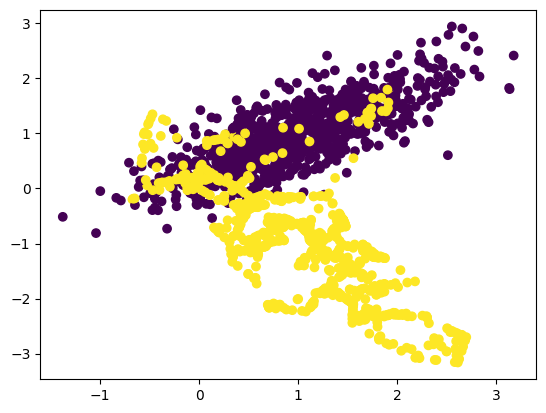

In [77]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])